In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### 
Imports the data-handling, visualization, preprocessing, and regression-evaluation libraries used throughout the lab. No output is expected at this setup stage.

In [6]:


# Load datasets
math_df = pd.read_csv(r"C:\Users\karun\Downloads\ML-Lab-2547229\LAB5\student\student-mat.csv", sep=";")
por_df = pd.read_csv(r"C:\Users\karun\Downloads\ML-Lab-2547229\LAB5\student\student-por.csv", sep=";")

# Columns that uniquely identify the same student
merge_columns = [
    "school", "sex", "age", "address", "famsize",
    "Pstatus", "Medu", "Fedu", "Mjob", "Fjob",
    "reason", "nursery", "internet"
]

# Merge the datasets
df = pd.merge(
    math_df,
    por_df,
    on=merge_columns,
    suffixes=("_math", "_por")
)

print(df.shape)
print(df.head())

(382, 53)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel_por freetime_por  goout_por  Dalc_por  Walc_por health_por  \
0          4            3          4         1         1          3   
1          5            3          3         1         1          3   
2          4            3          2         2         3          3   
3          3            2          2         1         1          5   
4          4            3          2         1         2          5   

  absences_por G1_por G2_por G3_por  
0            4      0     11     11  


### Loads the Mathematics and Portuguese student datasets, identifies shared students, and merges their records. The resulting dataset contains 382 matched students and 53 columns.

In [7]:
df.head()

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 53 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   school           382 non-null    str  
 1   sex              382 non-null    str  
 2   age              382 non-null    int64
 3   address          382 non-null    str  
 4   famsize          382 non-null    str  
 5   Pstatus          382 non-null    str  
 6   Medu             382 non-null    int64
 7   Fedu             382 non-null    int64
 8   Mjob             382 non-null    str  
 9   Fjob             382 non-null    str  
 10  reason           382 non-null    str  
 11  guardian_math    382 non-null    str  
 12  traveltime_math  382 non-null    int64
 13  studytime_math   382 non-null    int64
 14  failures_math    382 non-null    int64
 15  schoolsup_math   382 non-null    str  
 16  famsup_math      382 non-null    str  
 17  paid_math        382 non-null    str  
 18  activities_math  382 

school             0
sex                0
age                0
address            0
famsize            0
Pstatus            0
Medu               0
Fedu               0
Mjob               0
Fjob               0
reason             0
guardian_math      0
traveltime_math    0
studytime_math     0
failures_math      0
schoolsup_math     0
famsup_math        0
paid_math          0
activities_math    0
nursery            0
higher_math        0
internet           0
romantic_math      0
famrel_math        0
freetime_math      0
goout_math         0
Dalc_math          0
Walc_math          0
health_math        0
absences_math      0
G1_math            0
G2_math            0
G3_math            0
guardian_por       0
traveltime_por     0
studytime_por      0
failures_por       0
schoolsup_por      0
famsup_por         0
paid_por           0
activities_por     0
higher_por         0
romantic_por       0
famrel_por         0
freetime_por       0
goout_por          0
Dalc_por           0
Walc_por     

### Displays a sample of the merged dataset and summarizes its structure, descriptive statistics, and missing-value counts. This confirms the available features and helps assess data quality before modelling.

In [ ]:
#fill missing values with mean for numeric columns and mode for categorical columns
df.fillna(df.mean(numeric_only=True), inplace=True)
for col in df.select_dtypes(include="object"):
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\karun\AppData\Local\Temp\ipykernel_13980\3686505760.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):
C:\Users\karun\AppData\Local\Temp\ipykernel_13980\3686505760.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col

### Replaces missing numeric values with column means and missing categorical values with each column's most frequent value. This prepares the data for modelling by ensuring that no missing values remain.

In [9]:
print(df.select_dtypes(include="object").columns)
df = pd.get_dummies(
    df,
    drop_first=True
)

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian_math', 'schoolsup_math', 'famsup_math', 'paid_math',
       'activities_math', 'nursery', 'higher_math', 'internet',
       'romantic_math', 'guardian_por', 'schoolsup_por', 'famsup_por',
       'paid_por', 'activities_por', 'higher_por', 'romantic_por'],
      dtype='str')


C:\Users\karun\AppData\Local\Temp\ipykernel_13980\2973874107.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns)


### Lists the categorical columns and converts them into numeric dummy variables, dropping one category per feature to avoid redundant predictors. The dataset is now suitable for regression.

In [10]:
target = "G3_math"
X = df.drop(columns=[target])

y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Sets `G3_math` as the prediction target, uses all remaining columns as features, and creates an 80:20 training/test split. The held-out test set is reserved for final evaluation.

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Standardizes the feature values using statistics learned from the training set. Scaling puts predictors on comparable ranges and makes gradient descent more stable.

In [12]:
y_train = y_train.to_numpy()

y_test = y_test.to_numpy()
X_train = np.c_[
    np.ones(X_train.shape[0]),
    X_train
]

X_test = np.c_[
    np.ones(X_test.shape[0]),
    X_test
]

### Converts the targets to NumPy arrays and adds a bias (intercept) column of ones to both feature matrices. This allows the model to learn an intercept term.

In [13]:
# Number of training samples
m = X_train.shape[0]

# Number of features (including bias column)
n = X_train.shape[1]

# Initialize weights to zero
weights = np.zeros(n)

# Hyperparameters
learning_rate = 0.01
iterations = 1000

# Store cost at each iteration
cost_history = []

### Initializes the gradient-descent parameters, including zero weights, learning rate, iteration count, and an empty cost-history list. These settings control how the linear-regression model learns.

In [14]:
for i in range(iterations):

    # Step 1: Compute predictions
    predictions = X_train.dot(weights)

    # Step 2: Calculate errors
    errors = predictions - y_train

    # Step 3: Compute cost (Mean Squared Error Cost Function)
    cost = np.sum(errors ** 2) / (2 * m)
    cost_history.append(cost)

    # Step 4: Compute gradient
    gradient = X_train.T.dot(errors) / m

    # Step 5: Update weights
    weights = weights - learning_rate * gradient

### Runs batch gradient descent: predictions and errors are calculated each iteration, the mean-squared-error cost is recorded, and weights are updated to reduce that cost.

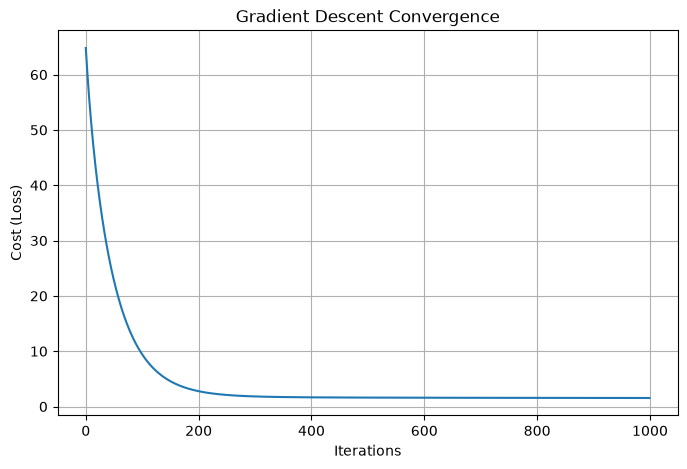

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history)

plt.title("Gradient Descent Convergence")
plt.xlabel("Iterations")
plt.ylabel("Cost (Loss)")
plt.grid(True)

plt.show()

### Plots the training cost against iterations. A downward trend indicates that gradient descent is converging and the model fit is improving.

In [16]:
def gradient_descent(X, y, learning_rate, iterations):

    m = X.shape[0]
    weights = np.zeros(X.shape[1])
    cost_history = []

    for _ in range(iterations):

        predictions = X.dot(weights)

        errors = predictions - y

        cost = np.sum(errors ** 2) / (2 * m)
        cost_history.append(cost)

        gradient = X.T.dot(errors) / m

        weights = weights - learning_rate * gradient

    return weights, cost_history

### Defines a reusable gradient-descent function that returns fitted weights and the cost history. It makes it possible to compare different learning rates consistently.

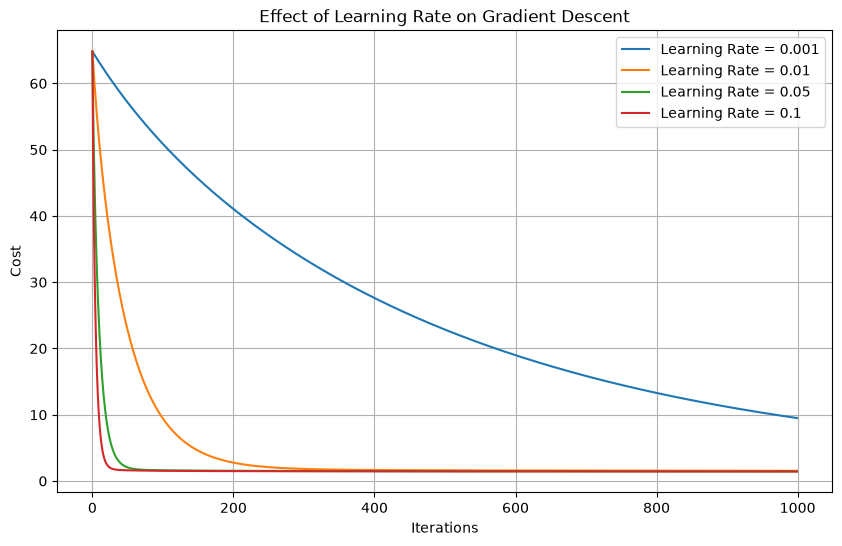

In [17]:
learning_rates = [0.001, 0.01, 0.05, 0.1]

plt.figure(figsize=(10, 6))

for lr in learning_rates:

    weights, history = gradient_descent(
        X_train,
        y_train,
        learning_rate=lr,
        iterations=1000
    )

    plt.plot(history, label=f"Learning Rate = {lr}")

plt.title("Effect of Learning Rate on Gradient Descent")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.grid(True)

plt.show()

### Trains the model using several learning rates and plots their convergence curves. The plot shows which rates reduce the loss efficiently without instability.

In [18]:
learning_rate = 0.01
iterations = 1000

weights, cost_history = gradient_descent(
    X_train,
    y_train,
    learning_rate,
    iterations
)

### Fits the final linear-regression model using the selected learning rate and iteration count. The resulting weights are used for test-set predictions.

In [19]:
y_pred = X_test.dot(weights)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 1.4267
Mean Squared Error (MSE): 4.6904
Root Mean Squared Error (RMSE): 2.1657
R² Score: 0.7898


### Evaluates predictions on the unseen test set. The model achieves MAE = 1.4267, RMSE = 2.1657, and R? = 0.7898, meaning it explains about 79% of the variation in Mathematics final grades.

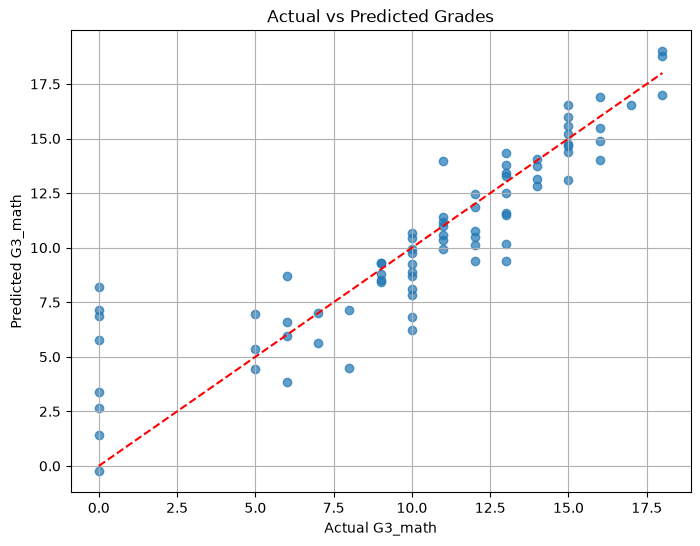

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual G3_math")
plt.ylabel("Predicted G3_math")
plt.title("Actual vs Predicted Grades")

plt.grid(True)
plt.show()

### Compares actual and predicted Mathematics final grades. Points close to the red diagonal represent accurate predictions; their overall proximity reflects the model's predictive performance.